# Notebook 3 — Professional Modeling, Validation, SHAP, and Deployment Artifacts

This notebook takes the design decisions from **Notebook 2** and turns them into a
stronger modeling workflow:

- apply the agreed outlier rule
- train on `log1p(SalePrice)`
- use a **real preprocessing pipeline**
- compare multiple models
- use cross-validation
- tune XGBoost with `GridSearchCV`
- run error analysis
- compute SHAP-based importance
- save deployment artifacts for the app

This notebook is intentionally more complete and presentation-ready than a minimal
training script.

## 0. Imports and setup

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

warnings.filterwarnings("ignore")

from xgboost import XGBRegressor

try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    SHAP_AVAILABLE = False

RANDOM_STATE = 42
DATA_PATH = Path("train.csv")
PLAN_PATH = Path("feature_design_plan.json")

## 1. Load raw data and Notebook 2 design plan

In [2]:
df = pd.read_csv(DATA_PATH)

if PLAN_PATH.exists():
    feature_plan = json.loads(PLAN_PATH.read_text())
else:
    # Fallback so the notebook remains runnable even if Notebook 2 artifacts were not saved yet.
    feature_plan = {
        "outlier_rule": {
            "description": "Remove extreme GrLivArea rows with comparatively low sale price",
            "rule": "(GrLivArea > 4000) & (SalePrice < 300000)"
        },
        "ordinal_cols": [
            "ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "HeatingQC", "KitchenQual",
            "FireplaceQu", "GarageQual", "GarageCond", "GarageFinish", "BsmtExposure",
            "BsmtFinType1", "BsmtFinType2", "Functional", "Fence", "PoolQC",
            "LandSlope", "LotShape", "PavedDrive", "Utilities"
        ],
        "target_encode_cols": ["Neighborhood", "Exterior1st", "Exterior2nd"],
        "log_transform_cols": [
            "LotArea", "GrLivArea", "1stFlrSF", "2ndFlrSF", "BsmtFinSF1",
            "BsmtUnfSF", "OpenPorchSF", "WoodDeckSF", "EnclosedPorch", "ScreenPorch"
        ]
    }

print(df.shape)
pd.Series({
    "rows": df.shape[0],
    "columns": df.shape[1],
    "target_encoded_columns": len(feature_plan.get("target_encode_cols", [])),
    "log_transformed_numeric_columns": len(feature_plan.get("log_transform_cols", [])),
})

(1460, 81)


rows                               1460
columns                              81
target_encoded_columns                3
log_transformed_numeric_columns      16
dtype: int64

## 2. Apply the agreed outlier rule and define the log target

In [3]:
outlier_mask = (df["GrLivArea"] > 4000) & (df["SalePrice"] < 300000)
df_model = df.loc[~outlier_mask].copy()

y = np.log1p(df_model["SalePrice"])
X = df_model.drop(columns=["SalePrice"])

print("Rows removed:", int(outlier_mask.sum()))
print("Modeling shape:", X.shape)

Rows removed: 2
Modeling shape: (1458, 80)


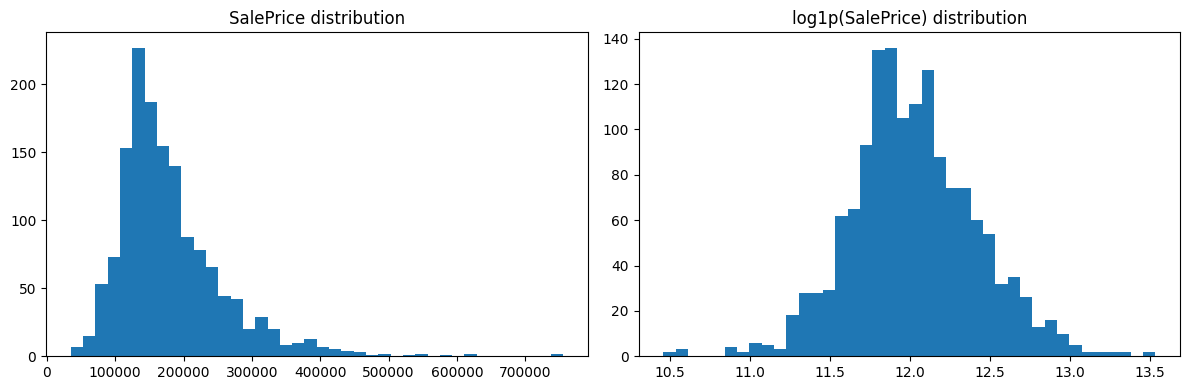

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_model["SalePrice"], bins=40)
axes[0].set_title("SalePrice distribution")
axes[1].hist(y, bins=40)
axes[1].set_title("log1p(SalePrice) distribution")
plt.tight_layout()
plt.show()

## 3. Train/test split

To stay close to your earlier workflow, this notebook uses a **time-style split**:

- train: `YrSold <= 2008`
- test:  `YrSold > 2008`

This is useful because it avoids letting later sales influence earlier training too directly.

In [5]:
train_mask = X["YrSold"] <= 2008
X_train = X.loc[train_mask].copy()
X_test  = X.loc[~train_mask].copy()
y_train = y.loc[train_mask].copy()
y_test  = y.loc[~train_mask].copy()

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (945, 80)
Test shape : (513, 80)


## 4. Custom preprocessing components

The next cells build a **real preprocessing system**:

- structural missingness handling
- ordinal mapping
- engineered features
- `log1p` on selected skewed numeric columns
- one-hot encoding for lower-cardinality nominal columns
- target encoding for selected higher-cardinality nominal columns

In [6]:
QUALITY_MAP = {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "None": 0}
STRUCTURAL_NONE_COLS = [
    "Alley","BsmtQual","BsmtCond","BsmtExposure","BsmtFinType1","BsmtFinType2",
    "FireplaceQu","GarageType","GarageFinish","GarageQual","GarageCond",
    "PoolQC","Fence","MiscFeature","MasVnrType"
]
ZERO_WHEN_MISSING_COLS = ["GarageYrBlt", "MasVnrArea"]
ORDINAL_MAPS = {
    "GarageFinish": {"None": 0, "Unf": 1, "RFn": 2, "Fin": 3},
    "BsmtExposure": {"None": 0, "No": 1, "Mn": 2, "Av": 3, "Gd": 4},
    "BsmtFinType1": {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},
    "BsmtFinType2": {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},
    "Functional": {"Sal": 0, "Sev": 1, "Maj2": 2, "Maj1": 3, "Mod": 4, "Min2": 5, "Min1": 6, "Typ": 7},
    "Fence": {"None": 0, "MnWw": 1, "GdWo": 2, "MnPrv": 3, "GdPrv": 4},
    "LandSlope": {"Sev": 0, "Mod": 1, "Gtl": 2},
    "LotShape": {"IR3": 0, "IR2": 1, "IR1": 2, "Reg": 3},
    "PavedDrive": {"N": 0, "P": 1, "Y": 2},
    "Utilities": {"ELO": 0, "NoSeWa": 1, "NoSewr": 2, "AllPub": 3},
}
QUALITY_COLS = ["ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "HeatingQC",
                "KitchenQual", "FireplaceQu", "GarageQual", "GarageCond", "PoolQC"]

In [7]:
# base estimator gives us the basic structure of custom pipeline
# transformermixin just reduce the work of fit & transform() repetitve use
class AmesFeatureBuilder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.input_columns_ = list(pd.DataFrame(X).columns)
        return self

    def transform(self, X):
        df = pd.DataFrame(X).copy()

        if "Id" in df.columns:
            df = df.drop(columns=["Id"])

        for col in STRUCTURAL_NONE_COLS:
            if col in df.columns:
                df[col] = df[col].fillna("None")
        for col in ZERO_WHEN_MISSING_COLS:
            if col in df.columns:
                df[col] = df[col].fillna(0)

        if "Electrical" in df.columns and not df["Electrical"].mode(dropna=True).empty:
            df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode(dropna=True)[0])

        for col in QUALITY_COLS:
            if col in df.columns:
                df[col] = df[col].fillna("None").map(QUALITY_MAP)

        for col, mapping in ORDINAL_MAPS.items():
            if col in df.columns:
                df[col] = df[col].fillna("None").map(mapping).astype(float)

        if {"YrSold", "YearBuilt"}.issubset(df.columns):
            df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
        if {"YrSold", "YearRemodAdd", "YearBuilt"}.issubset(df.columns):
            df["RemodAge"] = df["YrSold"] - df["YearRemodAdd"]
            df["IsRemodeled"] = (df["YearRemodAdd"] != df["YearBuilt"]).astype(int)
        if {"TotalBsmtSF", "1stFlrSF", "2ndFlrSF"}.issubset(df.columns):
            df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]
        porch_cols = ["OpenPorchSF", "EnclosedPorch", "3SsnPorch", "ScreenPorch"]
        if set(porch_cols).issubset(df.columns):
            df["TotalPorchSF"] = df[porch_cols].sum(axis=1)
        bath_cols = ["FullBath", "BsmtFullBath", "HalfBath", "BsmtHalfBath"]
        if set(bath_cols).issubset(df.columns):
            df["TotalBaths"] = (
                df["FullBath"] + df["BsmtFullBath"] + 0.5 * df["HalfBath"] + 0.5 * df["BsmtHalfBath"]
            )
        if "PoolArea" in df.columns:
            df["HasPool"] = (df["PoolArea"] > 0).astype(int)
        if "GarageArea" in df.columns:
            df["HasGarage"] = (df["GarageArea"] > 0).astype(int)
        if "Fireplaces" in df.columns:
            df["HasFireplace"] = (df["Fireplaces"] > 0).astype(int)
        if "2ndFlrSF" in df.columns:
            df["Has2ndFloor"] = (df["2ndFlrSF"] > 0).astype(int)
        if "WoodDeckSF" in df.columns:
            df["HasWoodDeck"] = (df["WoodDeckSF"] > 0).astype(int)
        if {"OverallQual", "GrLivArea"}.issubset(df.columns):
            df["QualArea"] = df["OverallQual"] * df["GrLivArea"]
        if "MoSold" in df.columns:
            season_map = {12:0,1:0,2:0,3:1,4:1,5:1,6:2,7:2,8:2,9:3,10:3,11:3}
            df["SeasonSold"] = df["MoSold"].map(season_map)
        if {"OverallQual", "OverallCond"}.issubset(df.columns):
            df["OverallScore"] = df["OverallQual"] + df["OverallCond"]
            df["QualCondScore"] = df["OverallQual"] * df["OverallCond"]
        if {"GrLivArea", "TotRmsAbvGrd"}.issubset(df.columns):
            df["LiveAreaPerRoom"] = df["GrLivArea"] / (df["TotRmsAbvGrd"] + 1)
        if {"BsmtFinSF1", "BsmtFinSF2", "TotalBsmtSF"}.issubset(df.columns):
            denom = df["TotalBsmtSF"].replace(0, np.nan)
            df["FinishedBsmtRatio"] = ((df["BsmtFinSF1"] + df["BsmtFinSF2"]) / denom).fillna(0)
        outdoor_cols = ["WoodDeckSF", "OpenPorchSF", "EnclosedPorch", "ScreenPorch"]
        if set(outdoor_cols).issubset(df.columns):
            df["TotalOutdoorSF"] = df[outdoor_cols].sum(axis=1)
        if {"YearBuilt", "YrSold"}.issubset(df.columns):
            df["IsNewHouse"] = (df["YearBuilt"] >= df["YrSold"] - 2).astype(int)
        if {"TotalSF", "GrLivArea"}.issubset(df.columns):
            denom = df["TotalSF"].replace(0, np.nan)
            df["AboveGroundRatio"] = (df["GrLivArea"] / denom).fillna(0)
        if {"GarageCars", "GarageArea"}.issubset(df.columns):
            df["GarageScore"] = df["GarageCars"] * df["GarageArea"]
        if {"TotalBaths", "BedroomAbvGr"}.issubset(df.columns):
            df["BathsPerBedroom"] = df["TotalBaths"] / (df["BedroomAbvGr"] + 1)
        return df

In [8]:
## this one got the issue
class MeanTargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, smoothing=20.0):
        self.smoothing = smoothing

    def fit(self, X, y):
        X = pd.DataFrame(X).copy()
        self.columns_ = list(X.columns)
        self.global_mean_ = float(np.mean(y))
        self.maps_ = {}
        y_series = pd.Series(y, index=X.index)

        for col in self.columns_:
            stats = pd.DataFrame({"x": X[col], "y": y_series}).groupby("x")["y"].agg(["mean", "count"])
            smooth = (stats["count"] * stats["mean"] + self.smoothing * self.global_mean_) / (stats["count"] + self.smoothing)
            self.maps_[col] = smooth.to_dict()
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        out = pd.DataFrame(index=X.index)
        for col in self.columns_:
            out[f"{col}__te"] = X[col].map(self.maps_[col]).fillna(self.global_mean_)
        return out

In [9]:
class MeanTargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, smoothing=20.0):
        self.smoothing = smoothing

    def fit(self, X, y):
        X = pd.DataFrame(X).copy()
        self.columns_ = list(X.columns)
        self.global_mean_ = float(np.mean(y))
        self.maps_ = {}
        y_series = pd.Series(y, index=X.index)

        for col in self.columns_:
            stats = pd.DataFrame({"x": X[col], "y": y_series}).groupby("x")["y"].agg(["mean", "count"])
            smooth = (stats["count"] * stats["mean"] + self.smoothing * self.global_mean_) / (stats["count"] + self.smoothing)
            self.maps_[col] = smooth.to_dict()
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        out = pd.DataFrame(index=X.index)
        for col in self.columns_:
            out[f"{col}__te"] = X[col].map(self.maps_[col]).fillna(self.global_mean_)
        return out

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = getattr(self, "columns_", [])
        return np.array([f"{col}__te" for col in input_features], dtype=object)

In [10]:
class LogTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cols):
        self.cols = cols

    def fit(self, X, y=None):
        self.cols_ = [c for c in self.cols if c in pd.DataFrame(X).columns]
        return self

    def transform(self, X):
        df = pd.DataFrame(X).copy()
        for col in self.cols_:
            df[col] = np.log1p(df[col].clip(lower=0))
        return df

## 5. Build the preprocessing pipeline from the Notebook 2 plan

In [11]:
feature_builder = AmesFeatureBuilder()
tmp_train = feature_builder.fit_transform(X_train)

ordinal_cols = [c for c in feature_plan.get("ordinal_cols", []) if c in tmp_train.columns]
target_encode_cols = [c for c in feature_plan.get("target_encode_cols", []) if c in tmp_train.columns]
log_transform_cols = [c for c in feature_plan.get("log_transform_cols", []) if c in tmp_train.columns]

numeric_cols = tmp_train.select_dtypes(include=np.number).columns.tolist()
numeric_non_te = [c for c in numeric_cols if c not in target_encode_cols]
onehot_cols = [c for c in tmp_train.select_dtypes(include="object").columns if c not in target_encode_cols]

preprocessor = Pipeline([
    ("log_selected_numeric", LogTransformer(cols=log_transform_cols)),
    ("columnwise", ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), numeric_non_te),
        ("onehot", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), onehot_cols),
        ("target", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("target_encoder", MeanTargetEncoder(smoothing=20.0))
        ]), target_encode_cols),
    ], remainder="drop", verbose_feature_names_out=False))
])

def make_model_pipeline(model):
    return Pipeline([
        ("feature_builder", AmesFeatureBuilder()),
        ("preprocessor", preprocessor),
        ("model", model)
    ])

baseline_models = {
    "Dummy": DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "XGBoost": XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.7,
        colsample_bytree=0.7,
        min_child_weight=5,
        reg_alpha=0.1,
        reg_lambda=5,
        n_jobs = -1
    )
}

## 6. Cross-validation for model comparison

In [12]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rows = []
for name, model in baseline_models.items():
    pipe = make_model_pipeline(model)
    cv_results = cross_validate(
        pipe, X_train, y_train, cv=cv,
        scoring=("neg_root_mean_squared_error", "neg_mean_absolute_error", "r2"),
        n_jobs=-1
    )
    rows.append({
        "model": name,
        "cv_rmse": -cv_results["test_neg_root_mean_squared_error"].mean(),
        "cv_mae": -cv_results["test_neg_mean_absolute_error"].mean(),
        "cv_r2": cv_results["test_r2"].mean(),
    })

cv_summary = pd.DataFrame(rows).sort_values("cv_rmse")
cv_summary

,model,cv_rmse,cv_mae,cv_r2
1,Linear Regression,0.114674,0.080695,0.912115
4,XGBoost,0.114712,0.079553,0.912823
3,Gradient Boosting,0.118145,0.082856,0.907871
2,Random Forest,0.129715,0.089963,0.888588
0,Dummy,0.390951,0.304622,-0.007220


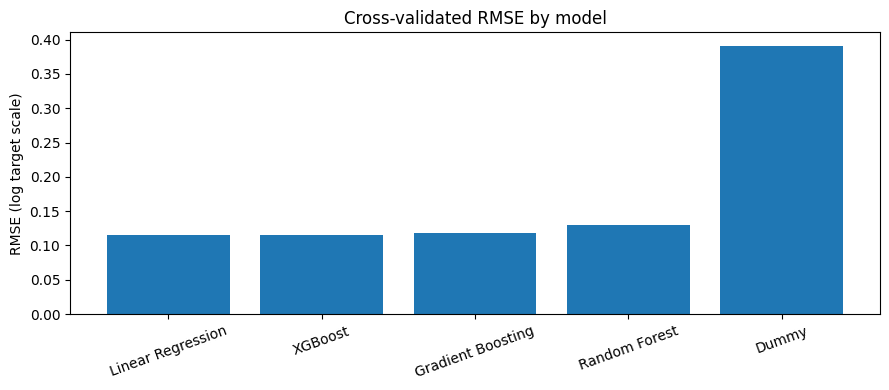

In [13]:
fig = plt.figure(figsize=(9, 4))
plt.bar(cv_summary["model"], cv_summary["cv_rmse"])
plt.xticks(rotation=20)
plt.title("Cross-validated RMSE by model")
plt.ylabel("RMSE (log target scale)")
plt.tight_layout()
plt.show()

## 7. Tune XGBoost with GridSearchCV

In [14]:
xgb_grid = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [3, 4],
    "model__learning_rate": [0.03, 0.05],
    "model__subsample": [0.7, 0.8],
    "model__colsample_bytree": [0.7, 0.8],
    "model__min_child_weight": [3, 5],
    "model__reg_alpha": [0, 0.1],
    "model__reg_lambda": [1, 5]
}


xgb_base = make_model_pipeline(
    XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=1,
    )
)

grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=xgb_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=3,
    verbose=1,
)

# Run this cell when you want the full tuning search.
grid.fit(X_train, y_train)
best_pipeline = grid.best_estimator_
best_params = grid.best_params_

Fitting 5 folds for each of 256 candidates, totalling 1280 fits


In [27]:
best_pipeline.fit(X_train, y_train)

Pipeline(steps=[('feature_builder', AmesFeatureBuilder()),
                ('preprocessor',
                 Pipeline(steps=[('log_selected_numeric',
                                  LogTransformer(cols=['LotArea', '3SsnPorch',
                                                       'LowQualFinSF',
                                                       'BsmtFinSF2',
                                                       'ScreenPorch',
                                                       'EnclosedPorch',
                                                       'MasVnrArea',
                                                       'OpenPorchSF',
                                                       'WoodDeckSF',
                                                       'LotFrontage',
                                                       'MSSubClass',
                                                       'GrLivArea', 'BsmtUnfSF',
                                                       '1stFlrSF', '2ndFlrSF',
                                                       'BsmtFinSF1'])),
                                 ('colum...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=3, max_leaves=None, min_child_weight=3,
                              missing=nan, monotone_constraints=None,
                              multi_strategy=None, n_estimators=300, n_jobs=1,
                              num_parallel_tree=None, ...))])

## 8. Final train/test evaluation

In [16]:
def regression_metrics(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

train_pred = best_pipeline.predict(X_train)
test_pred = best_pipeline.predict(X_test)

metrics_df = pd.DataFrame({
    "train": regression_metrics(y_train, train_pred),
    "test": regression_metrics(y_test, test_pred),
})
metrics_df

,train,test
RMSE,0.059290,0.128478
MAE,0.044996,0.088079
R2,0.976962,0.904140


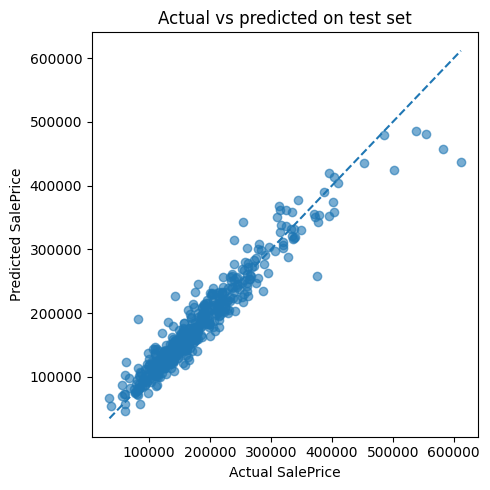

In [17]:
fig = plt.figure(figsize=(5, 5))
plt.scatter(np.expm1(y_test), np.expm1(test_pred), alpha=0.6)
lims = [np.expm1(y_test).min(), np.expm1(y_test).max()]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs predicted on test set")
plt.tight_layout()
plt.show()

## 9. Error analysis

In [18]:
error_df = X_test.copy()
error_df["actual_log"] = y_test.values
error_df["pred_log"] = test_pred
error_df["actual_price"] = np.expm1(error_df["actual_log"])
error_df["pred_price"] = np.expm1(error_df["pred_log"])
error_df["abs_error"] = (error_df["actual_price"] - error_df["pred_price"]).abs()
error_df["signed_error"] = error_df["pred_price"] - error_df["actual_price"]
error_df = error_df.sort_values("abs_error", ascending=False)

error_df[["Neighborhood", "GrLivArea", "OverallQual", "actual_price", "pred_price", "abs_error"]].head(10)

,Neighborhood,GrLivArea,OverallQual,actual_price,pred_price,abs_error
898,NridgHt,2364,9,611657.0,436982.156250,174674.843750
803,NridgHt,2822,9,582933.0,458034.656250,124898.343750
313,Timber,2036,7,375000.0,258471.468750,116528.531250
632,NWAmes,1411,7,82500.0,190293.515625,107793.515625
581,NridgHt,2042,8,253293.0,343651.093750,90358.093750
588,ClearCr,1473,5,143000.0,226804.937500,83804.937500
178,StoneBr,2234,9,501837.0,423963.937500,77873.062500
963,CollgCr,1800,9,239000.0,315335.937500,76335.937500
440,NridgHt,2402,10,555000.0,480422.000000,74578.000000
66,NAmes,2207,7,180000.0,246280.703125,66280.703125


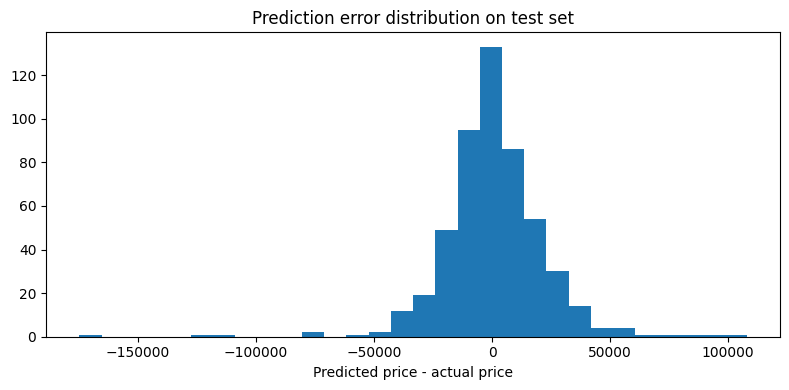

In [19]:
fig = plt.figure(figsize=(8, 4))
plt.hist(error_df["signed_error"], bins=30)
plt.title("Prediction error distribution on test set")
plt.xlabel("Predicted price - actual price")
plt.tight_layout()
plt.show()

## 10. SHAP / feature importance

In [20]:
feature_builder_fitted = best_pipeline.named_steps["feature_builder"]
preprocessor_fitted = best_pipeline.named_steps["preprocessor"]
model_fitted = best_pipeline.named_steps["model"]

X_test_engineered = feature_builder_fitted.transform(X_test)
X_test_transformed = preprocessor_fitted.transform(X_test_engineered)

feature_names = best_pipeline.named_steps["preprocessor"].named_steps["columnwise"].get_feature_names_out().tolist()

if SHAP_AVAILABLE:
    explainer = shap.TreeExplainer(model_fitted)
    shap_values = explainer.shap_values(X_test_transformed)
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    shap_importance = (
        pd.DataFrame({"feature": feature_names, "mean_abs_shap": mean_abs_shap})
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index(drop=True)
    )
else:
    importance = getattr(model_fitted, "feature_importances_", np.zeros(len(feature_names)))
    shap_importance = (
        pd.DataFrame({"feature": feature_names, "mean_abs_shap": importance})
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index(drop=True)
    )

shap_importance.head(20)

,feature,mean_abs_shap
0,QualArea,0.081910
1,TotalSF,0.078288
2,OverallQual,0.040239
3,KitchenQual,0.021537
4,LotArea,0.018998
5,TotalBaths,0.015132
6,FireplaceQu,0.013908
7,QualCondScore,0.013303
8,YearRemodAdd,0.013090
9,GarageFinish,0.012544


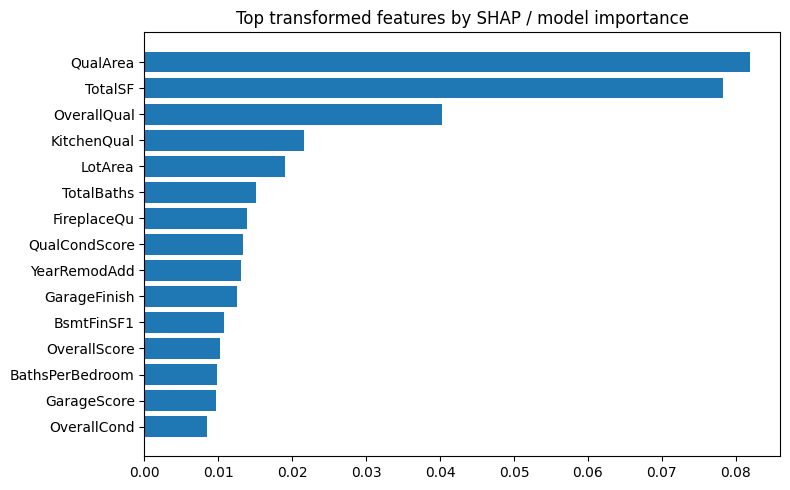

In [21]:
fig = plt.figure(figsize=(8, 5))
top_plot = shap_importance.head(15).sort_values("mean_abs_shap")
plt.barh(top_plot["feature"], top_plot["mean_abs_shap"])
plt.title("Top transformed features by SHAP / model importance")
plt.tight_layout()
plt.show()

In [22]:
shap_importance[shap_importance["feature"] == "Neighborhood"]

,feature,mean_abs_shap


In [23]:
shap_importance.head(20)

,feature,mean_abs_shap
0,QualArea,0.081910
1,TotalSF,0.078288
2,OverallQual,0.040239
3,KitchenQual,0.021537
4,LotArea,0.018998
5,TotalBaths,0.015132
6,FireplaceQu,0.013908
7,QualCondScore,0.013303
8,YearRemodAdd,0.013090
9,GarageFinish,0.012544


## 11. Save deployment artifacts

In [24]:
metrics_df.to_dict()

{'train': {'RMSE': 0.059289907905947785,
  'MAE': 0.04499607705989068,
  'R2': 0.976962300991185},
 'test': {'RMSE': 0.12847775730658745,
  'MAE': 0.08807855788869448,
  'R2': 0.9041402492961057}}

In [25]:
import pickle

# defaults for the app
defaults = {}
for col in X_train.columns:
    if pd.api.types.is_numeric_dtype(X_train[col]):
        defaults[col] = float(X_train[col].median())
    else:
        mode = X_train[col].mode(dropna=True)
        defaults[col] = None if mode.empty else mode.iloc[0]

top_ui_features = [
    "Neighborhood", "OverallQual", "GrLivArea", "TotalBsmtSF", "1stFlrSF",
    "2ndFlrSF", "YearBuilt", "YearRemodAdd", "KitchenQual", "FullBath", "GarageCars"
]

model_meta_real = {
    "target": "SalePrice_log1p",
    "train_rows": int(X_train.shape[0]),
    "test_rows": int(X_test.shape[0]),
    "cv_summary": cv_summary.to_dict(orient="records"),
    "final_metrics": metrics_df.to_dict(),
    "top_transformed_features": shap_importance.head(20).to_dict(orient="records"),
    "best_params": best_params,
    "target_encode_cols": target_encode_cols,
    "onehot_cols": onehot_cols,
    "ordinal_cols": ordinal_cols,
}

with open("model.pkl", "wb") as f:
    pickle.dump(best_pipeline, f)

with open("defaults.json", "w") as f:
    json.dump(defaults, f, indent=2)

with open("ui_feature_plan.json", "w") as f:
    json.dump({"ui_features": top_ui_features}, f, indent=2)

with open("model_metadata.json", "w") as f:
    json.dump(model_meta_real, f, indent=2)

print("Saved: model.pkl, defaults.json, ui_feature_plan.json, model_metadata.json")

Saved: model.pkl, defaults.json, ui_feature_plan.json, model_metadata.json


## 12. Summary

This notebook is now the **professional modeling notebook**:

- compares multiple models
- uses cross-validation
- includes a GridSearchCV tuning path
- keeps a real preprocessing pipeline
- evaluates on a held-out test split
- includes error analysis and importance plots
- saves deployment artifacts for the app

If you want an even stronger portfolio version later, the next upgrade would be:
- richer grouped SHAP interpretation back to raw feature families
- more detailed residual slicing by neighborhood / quality bands
- model-calibration style comparison tables